In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
sales= pd.read_csv("/Users/kushal09/Documents/Documents - Krrish's MacBook Air/Career247 /Capstone_project/inventory_optimization/data/raw/sales_fact.csv")
products = pd.read_csv("/Users/kushal09/Documents/Documents - Krrish's MacBook Air/Career247 /Capstone_project/inventory_optimization/data/raw/products_master.csv")
suppliers = pd.read_csv("/Users/kushal09/Documents/Documents - Krrish's MacBook Air/Career247 /Capstone_project/inventory_optimization/data/raw/suppliers_master.csv")
inventory = pd.read_csv("/Users/kushal09/Documents/Documents - Krrish's MacBook Air/Career247 /Capstone_project/inventory_optimization/data/raw/inventory_snapshot.csv")

In [5]:
sales['date'] = pd.to_datetime(sales['date'])

/var/folders/qm/8t8rxfy10f7b3mdcgk6yhkgh0000gp/T/ipykernel_62265/1173596365.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales['date'] = pd.to_datetime(sales['date'])


In [ ]:
daily_sales = (sales.groupby('date')['units_sold'].sum().reset_index())

<Axes: xlabel='date'>

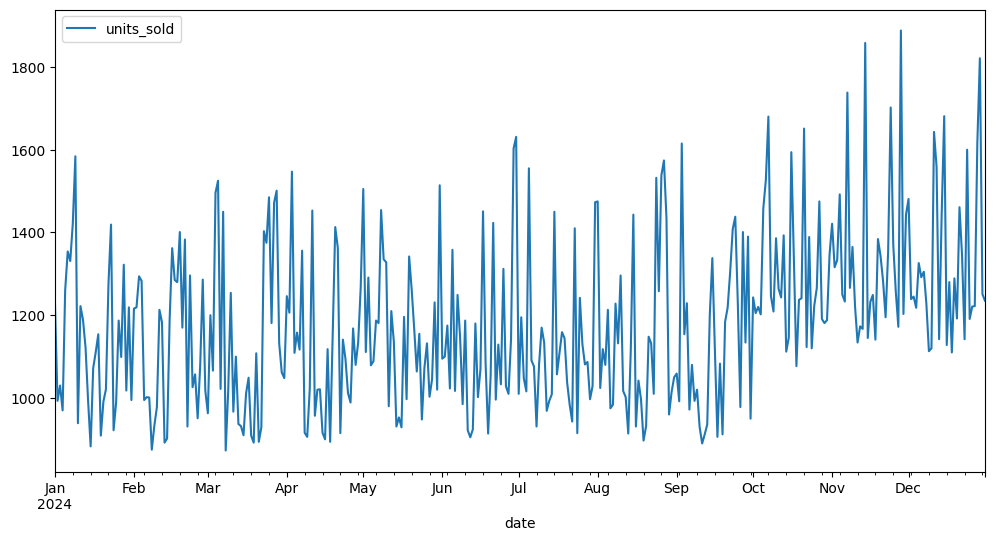

In [7]:
daily_sales.plot(
    x='date',
    y='units_sold',
    figsize=(12, 6),
)

In [8]:
# CAtegory Analysis

sales_product = sales.merge(products , on = 'sku_id' , how ='left')

In [9]:
category_sales = (sales_product.groupby('category')['units_sold'].sum().sort_values(ascending=False))

<Axes: xlabel='category'>

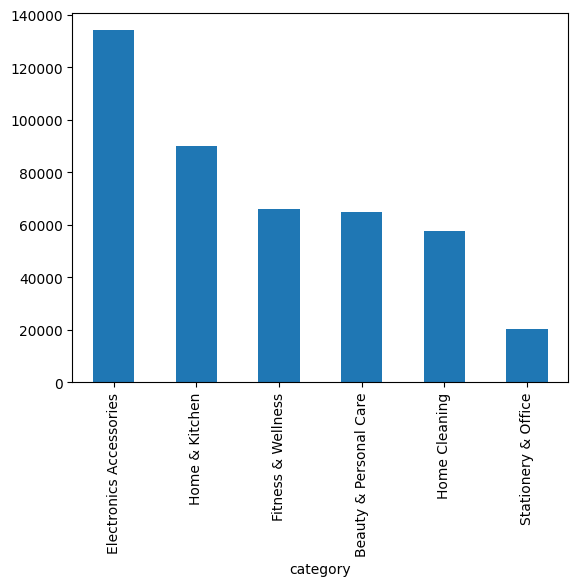

In [10]:
category_sales.plot(
    x='category',
    y='units_sold',
    kind = 'bar'
)
# Here we have found that the category with the highhest sales is the 'Electronics Accesories' followed by 'Home Appliances' and 'Mobile Phones'. This insight can help the company to focus on these categories for inventory optimization and marketing strategies.

In [11]:
sku_sales = (sales_product.groupby('sku_id')['units_sold'].sum().sort_values(ascending=False))

<Axes: xlabel='sku_id'>

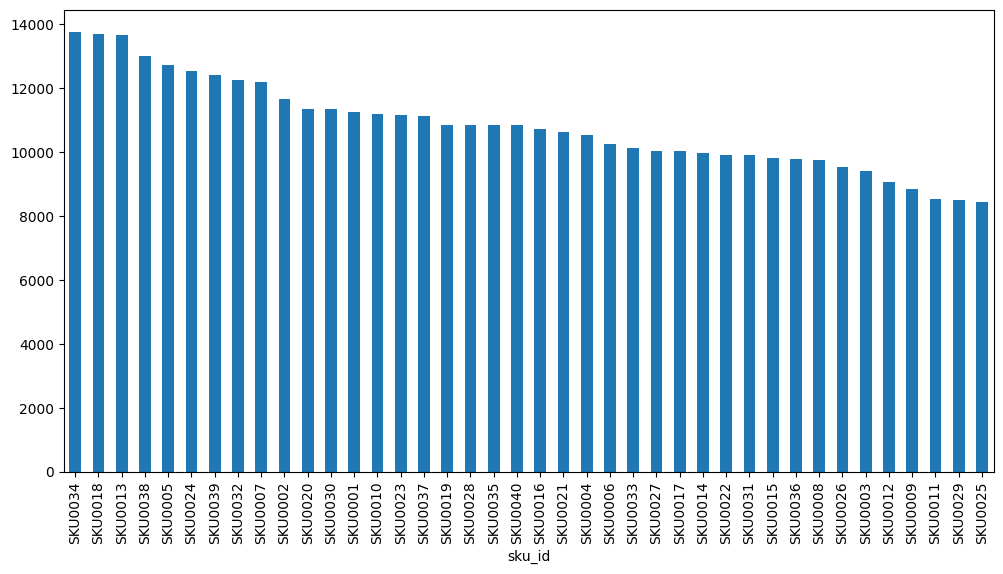

In [12]:
sku_sales.plot(
    x='sku_id',
    y='units_sold',
    kind = 'bar',
    figsize=(12,6)
)
# Top 10 SKUs with the highest sales. This insight can help the company to indentify  the most pop[ular products and ensure that they are well stocked to meet customer demand. Additionally, the company can analyze the characteristics of these top-selling SKUs to inform inventory optimization and marketing strategies for similar products.
# These will later become ABC classification of the products.

In [29]:
sales_promo=(sales.groupby('promo_flag')['units_sold'].sum())
sales_discount = (sales.groupby('discount_pct')['units_sold'].sum())
print(sales_promo)
print(sales_discount)
# This shows that the promoflag does not made much impact in increase in the demand

promo_flag
0    291819
1    140470
Name: units_sold, dtype: int64
discount_pct
0.0000     55
0.0001    370
0.0002    212
0.0003    356
0.0004    545
         ... 
0.4992     75
0.4994    164
0.4995     46
0.4996     41
0.4999     82
Name: units_sold, Length: 3405, dtype: int64


In [46]:
sales['promo_flag'].value_counts()

promo_flag
0    10970
1     3670
Name: count, dtype: int64

<Axes: xlabel='discount_pct'>

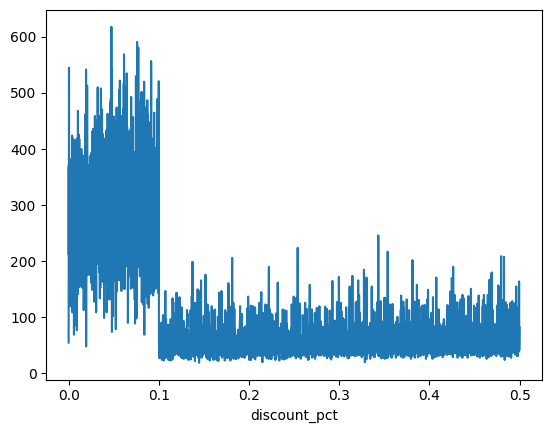

In [ ]:
sales_discount.plot(
    x='Discount',
    y ='Units_sold'
)
# From this graph we can interpret that the increase in discount precentage doesnot increase the demand

In [39]:
# Festival analysis
sales_fest = (sales.groupby('is_festival_month')['units_sold'].median())

In [40]:
sales_fest

is_festival_month
0    27.0
1    32.0
Name: units_sold, dtype: float64

In [41]:
sales.groupby('day_of_week')['units_sold'].mean()

day_of_week
0    29.191981
1    29.129245
2    29.191827
3    29.689423
4    28.816346
5    29.877885
6    30.812981
Name: units_sold, dtype: float64

In [45]:
sales.groupby('season_tag')['units_sold'].mean()

season_tag
festive    33.054620
monsoon    28.302869
summer     28.425543
winter     28.301667
Name: units_sold, dtype: float64

In [56]:
print(sales[['discount_pct' , 'units_sold']].corr())
print("============================================")
print(sales[['day_of_week' , 'units_sold']].corr())
print("============================================")
print(sales[['is_festival_month' , 'units_sold']].corr())



#Correlation tells about the  measurements of the correlation

              discount_pct  units_sold
discount_pct      1.000000    0.632785
units_sold        0.632785    1.000000
             day_of_week  units_sold
day_of_week     1.000000    0.055654
units_sold      0.055654    1.000000
                   is_festival_month  units_sold
is_festival_month           1.000000    0.266417
units_sold                  0.266417    1.000000


In [59]:
sales.groupby(
    pd.cut(
        sales["discount_pct"],
        bins=[0,0.1,0.2,0.3,0.4,0.5]
    )
)["units_sold"].sum()
# This will show average demand per discount bucket
# Much easier to interpret than scatter plot


/var/folders/qm/8t8rxfy10f7b3mdcgk6yhkgh0000gp/T/ipykernel_62265/512931546.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales.groupby(


discount_pct
(0.0, 0.1]    291764
(0.1, 0.2]     33699
(0.2, 0.3]     33090
(0.3, 0.4]     36313
(0.4, 0.5]     37368
Name: units_sold, dtype: int64

In [75]:
num_cols = sales.select_dtypes(include=['number'])

In [77]:
num_cols.corr()

,units_sold,selling_price,gross_revenue,promo_flag,discount_pct,month,week_of_year,day_of_week,is_weekend,is_festival_month,...,weather_index,campaign_intensity,traffic_index,competitor_price_index,competitor_stockout_flag,bundle_offer_flag,stock_visibility_score,rating_score,review_volume,product_visibility_rank
units_sold,1.000000,-0.137783,0.273976,0.659597,0.632785,2.039708e-01,2.007818e-01,5.565445e-02,6.714721e-02,2.664167e-01,...,-7.945127e-02,5.091667e-01,2.500459e-01,-5.361590e-02,1.333852e-01,8.128224e-03,0.020677,5.205577e-02,3.135770e-02,-0.139664
selling_price,-0.137783,1.000000,0.884221,-0.219009,-0.246556,7.221922e-03,5.692680e-03,8.859860e-03,1.010741e-02,9.796568e-03,...,9.914018e-03,-1.108566e-01,1.243110e-02,2.158553e-03,2.938387e-03,1.411224e-03,0.088215,-4.098827e-02,1.028946e-02,-0.007928
gross_revenue,0.273976,0.884221,1.000000,0.024032,-0.026114,1.013795e-01,9.779228e-02,4.065710e-02,4.638009e-02,1.340361e-01,...,-2.544726e-02,8.523296e-02,1.307454e-01,-2.342827e-02,6.539939e-02,4.034805e-03,0.066096,-2.474216e-02,3.999329e-03,-0.069467
promo_flag,0.659597,-0.219009,0.024032,1.000000,0.862753,-2.955189e-02,-2.061973e-02,-4.616793e-02,-5.620509e-02,-4.305702e-02,...,-3.552379e-02,5.234710e-01,-5.908340e-02,-1.211279e-02,-1.342388e-02,6.540961e-03,-0.016834,1.076184e-02,1.132712e-02,0.001441
discount_pct,0.632785,-0.246556,-0.026114,0.862753,1.000000,-2.899191e-02,-2.291615e-02,-4.471306e-02,-4.875611e-02,-4.006417e-02,...,-3.117009e-02,4.521336e-01,-5.233171e-02,-5.030944e-03,-1.232405e-02,1.029394e-04,-0.015434,1.837243e-02,4.139499e-03,0.005671
month,0.203971,0.007222,0.101379,-0.029552,-0.028992,1.000000e+00,9.670278e-01,6.152132e-03,8.038060e-03,7.532451e-01,...,-6.718900e-02,-5.163538e-02,6.481204e-01,-1.624554e-02,-3.909038e-03,3.474745e-02,0.003380,1.701106e-16,-2.386190e-16,0.006177
week_of_year,0.200782,0.005693,0.097792,-0.020620,-0.022916,9.670278e-01,1.000000e+00,1.146431e-02,5.819878e-03,7.193320e-01,...,-5.997920e-02,-3.472835e-02,6.143637e-01,1.208002e-04,8.440340e-03,4.632462e-02,0.003266,1.384368e-15,-5.847466e-16,0.009724
day_of_week,0.055654,0.008860,0.040657,-0.046168,-0.044713,6.152132e-03,1.146431e-02,1.000000e+00,7.905194e-01,-2.336460e-03,...,2.706455e-02,-9.520529e-02,2.528911e-01,-4.770159e-02,-1.038184e-02,5.936186e-02,-0.002610,1.351339e-16,-8.947486e-17,-0.000234
is_weekend,0.067147,0.010107,0.046380,-0.056205,-0.048756,8.038060e-03,5.819878e-03,7.905194e-01,1.000000e+00,-1.984115e-03,...,4.784232e-03,-1.045236e-01,3.145601e-01,-6.246835e-03,-3.676790e-02,1.055411e-02,-0.000964,1.121883e-16,-1.298997e-16,0.002586
is_festival_month,0.266417,0.009797,0.134036,-0.043057,-0.040064,7.532451e-01,7.193320e-01,-2.336460e-03,-1.984115e-03,1.000000e+00,...,-3.842819e-02,-6.550897e-02,8.596560e-01,-4.531957e-02,8.746789e-03,-1.504344e-03,0.001776,2.782826e-16,-2.145248e-16,0.004625


In [80]:
sales[['campaign_intensity' , 'units_sold']].head()

,campaign_intensity,units_sold
0,1,28
1,0,27
2,0,27
3,0,29
4,1,37


In [84]:
sales.groupby('campaign_intensity')['units_sold'].sum()

campaign_intensity
0    251204
1    114490
2     66595
Name: units_sold, dtype: int64

In [85]:
sales_product.groupby(
    'category'
)['units_sold'].agg(['mean','sum' , 'std']).sort_values('sum' , ascending = False)

,mean,sum,std
category,,,
Electronics Accessories,33.293095,134038,7.252982
Home & Kitchen,30.714139,89931,7.578577
Fitness & Wellness,25.769321,66021,6.307142
Beauty & Personal Care,29.441257,64653,6.971188
Home Cleaning,26.140255,57404,7.063616
Stationery & Office,27.653005,20242,7.235520


In [87]:
sku_stats = sales_product.groupby('sku_id')['units_sold'].agg(['mean' , 'std'])

sku_stats['cv'] = (
    sku_stats['std'] / sku_stats['mean']
)

In [88]:
sku_stats.head()

,mean,std,cv
sku_id,,,
SKU0001,30.704918,6.810574,0.221807
SKU0002,31.811475,8.125723,0.255434
SKU0003,25.683060,7.396637,0.287997
SKU0004,28.751366,7.191009,0.250110
SKU0005,34.748634,7.135263,0.205339


In [90]:
sales_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      14640 non-null  datetime64[ns]
 1   sku_id                    14640 non-null  object        
 2   units_sold                14640 non-null  int64         
 3   selling_price             14640 non-null  float64       
 4   gross_revenue             14640 non-null  float64       
 5   promo_flag                14640 non-null  int64         
 6   discount_pct              14640 non-null  float64       
 7   month                     14640 non-null  int64         
 8   week_of_year              14640 non-null  int64         
 9   day_of_week               14640 non-null  int64         
 10  is_weekend                14640 non-null  int64         
 11  is_festival_month         14640 non-null  int64         
 12  is_payday_period  

In [94]:
sup_unit = sales_product.groupby('supplier_id')['units_sold'].sum()

<Axes: xlabel='supplier_id'>

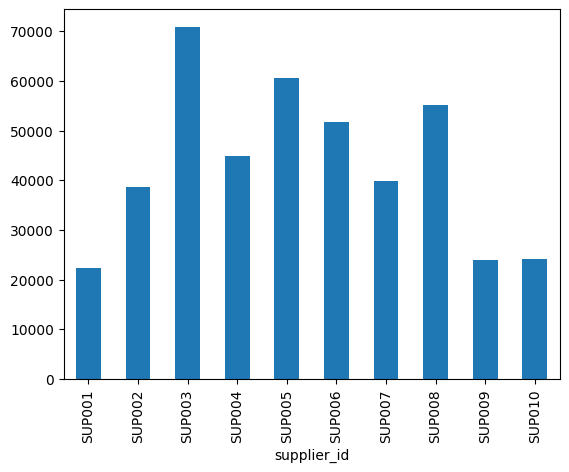

In [96]:
sup_unit.plot(kind='bar',
              x = 'supplier' , 
              y = 'Units_sold')

In [ ]:
sales_product.groupby('month')['units_sold'].sum()

month
1     35224
2     32700
3     35165
4     33594
5     35847
6     34151
7     34527
8     35468
9     33972
10    40171
11    40332
12    41138
Name: units_sold, dtype: int64

In [101]:
num_cols = [
    "units_sold",
    "discount_pct",
    "traffic_index",
    "weather_index",
    "campaign_intensity",
    "rating_score",
    "review_volume"
]

sales[num_cols].corr()

,units_sold,discount_pct,traffic_index,weather_index,campaign_intensity,rating_score,review_volume
units_sold,1.000000,0.632785,2.500459e-01,-7.945127e-02,5.091667e-01,5.205577e-02,3.135770e-02
discount_pct,0.632785,1.000000,-5.233171e-02,-3.117009e-02,4.521336e-01,1.837243e-02,4.139499e-03
traffic_index,0.250046,-0.052332,1.000000e+00,-1.421116e-02,-9.903293e-02,-1.559362e-14,8.366786e-15
weather_index,-0.079451,-0.031170,-1.421116e-02,1.000000e+00,-9.489629e-02,1.832639e-15,-1.347398e-15
campaign_intensity,0.509167,0.452134,-9.903293e-02,-9.489629e-02,1.000000e+00,-9.660070e-17,-6.096301e-18
rating_score,0.052056,0.018372,-1.559362e-14,1.832639e-15,-9.660070e-17,1.000000e+00,2.006715e-03
review_volume,0.031358,0.004139,8.366786e-15,-1.347398e-15,-6.096301e-18,2.006715e-03,1.000000e+00


<Axes: >

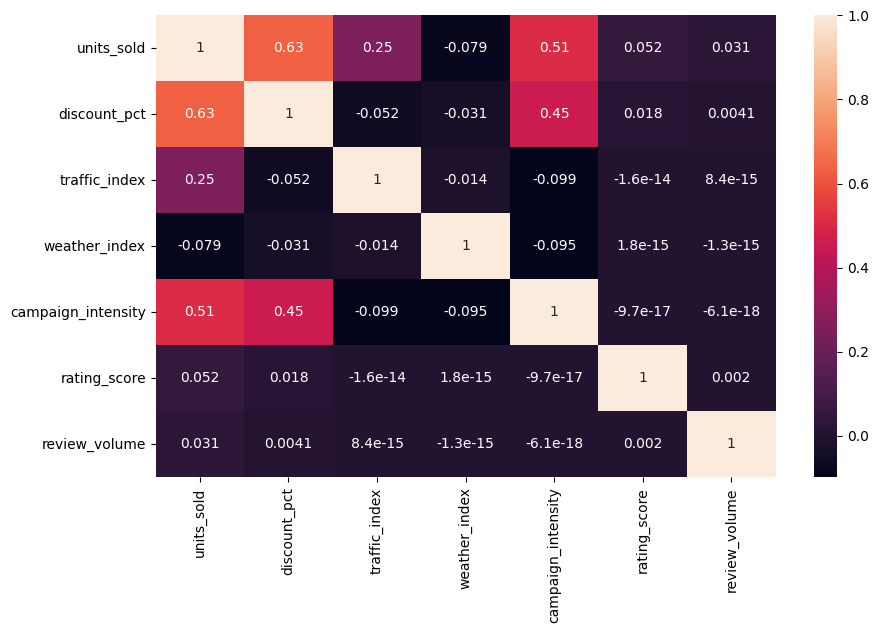

In [103]:
plt.figure(figsize=(10 , 6))
sns.heatmap(
    sales[num_cols].corr(),
    annot = True
)

In [115]:
weekly_sold = sales.groupby('week_of_year')['units_sold'].sum()

In [123]:
print((weekly_sold > 7500).value_counts())

units_sold
True     42
False    10
Name: count, dtype: int64


In [127]:
sales[['day_of_week','units_sold']].corr()

,day_of_week,units_sold
day_of_week,1.000000,0.055654
units_sold,0.055654,1.000000


In [132]:
sales[['day_of_week' , 'units_sold']]

,day_of_week,units_sold
0,0,28
1,1,27
2,2,27
3,3,29
4,4,37
...,...,...
14635,4,33
14636,5,38
14637,6,40
14638,0,27


In [133]:
sales[['selling_price' , 'units_sold']].corr()

,selling_price,units_sold
selling_price,1.000000,-0.137783
units_sold,-0.137783,1.000000


In [138]:
len(sales['sku_id'].value_counts())

40

In [139]:
sku_performance = sales.groupby('sku_id').agg(
    total_units = ('units_sold' , 'sum'),
    average_daily_units = ('units_sold' , 'mean'),
    days_with_sales=('units_sold' , 'count')
).reset_index()

In [145]:
top_selling = sku_performance.sort_values(by='total_units' , ascending = False).head(10)
print("--- TOP 10 SELLING PRODUCTS ---")
print(top_selling)

--- TOP 10 SELLING PRODUCTS ---
     sku_id  total_units  average_daily_units  days_with_sales
33  SKU0034        13755            37.581967              366
17  SKU0018        13702            37.437158              366
12  SKU0013        13656            37.311475              366
37  SKU0038        13001            35.521858              366
4   SKU0005        12718            34.748634              366
23  SKU0024        12515            34.193989              366
38  SKU0039        12417            33.926230              366
31  SKU0032        12248            33.464481              366
6   SKU0007        12175            33.265027              366
1   SKU0002        11643            31.811475              366


In [144]:
least_selling = sku_performance.sort_values(by="total_units", ascending=True).head(10)
print("\n--- BOTTOM 10 LEAST SELLING PRODUCTS ---")
print(least_selling)


--- BOTTOM 10 LEAST SELLING PRODUCTS ---
     sku_id  total_units  average_daily_units  days_with_sales
24  SKU0025         8429            23.030055              366
28  SKU0029         8497            23.215847              366
10  SKU0011         8540            23.333333              366
8   SKU0009         8832            24.131148              366
11  SKU0012         9071            24.784153              366
2   SKU0003         9400            25.683060              366
25  SKU0026         9524            26.021858              366
7   SKU0008         9761            26.669399              366
35  SKU0036         9786            26.737705              366
14  SKU0015         9826            26.846995              366


In [146]:
category_performance = sales_product.groupby("category").agg(
    total_units=('units_sold', 'sum'),
    avg_units_per_order=('units_sold', 'mean')
).sort_values(by="total_units", ascending=False).reset_index()

In [147]:
category_performance

,category,total_units,avg_units_per_order
0,Electronics Accessories,134038,33.293095
1,Home & Kitchen,89931,30.714139
2,Fitness & Wellness,66021,25.769321
3,Beauty & Personal Care,64653,29.441257
4,Home Cleaning,57404,26.140255
5,Stationery & Office,20242,27.653005


In [148]:
total_warehouse_sales = category_performance['total_units'].sum()
category_performance['demand_share_pct'] = (category_performance['total_units'] / total_warehouse_sales) * 100

print("--- CATEGORY DEMAND SHARE ---")
print(category_performance)

--- CATEGORY DEMAND SHARE ---
                  category  total_units  avg_units_per_order  demand_share_pct
0  Electronics Accessories       134038            33.293095         31.006572
1           Home & Kitchen        89931            30.714139         20.803444
2       Fitness & Wellness        66021            25.769321         15.272422
3   Beauty & Personal Care        64653            29.441257         14.955967
4            Home Cleaning        57404            26.140255         13.279080
5      Stationery & Office        20242            27.653005          4.682516


In [149]:
category_seasonality  = sales_product.pivot_table(
    index = 'category',
    columns = 'season_tag',
    values = 'units_sold',
    aggfunc = 'mean'
)

In [150]:
category_seasonality

season_tag,festive,monsoon,summer,winter
category,,,,
Beauty & Personal Care,33.021739,28.154372,28.367754,28.213889
Electronics Accessories,36.864625,32.123696,32.062253,32.081818
Fitness & Wellness,29.503106,24.592506,24.355590,24.604762
Home & Kitchen,33.961957,29.513320,29.811141,29.560417
Home Cleaning,29.708333,24.763661,25.239130,24.850000
Stationery & Office,31.038043,26.495902,26.858696,26.033333


In [152]:
sku_volatility = sales_product.groupby('sku_id').agg(
    mean_demand = ('units_sold', 'mean'),
    std_demand = ('units_sold' , 'std')
).reset_index()

sku_volatility['cv'] = sku_volatility['std_demand'] / sku_volatility['mean_demand']


def classify_xyz(cv):
    if cv<0.2: return 'X (stable)'
    elif cv<=0.5 : return 'Y (Moderate)'
    else: return 'Z (Highly Volatile)'

sku_volatility['xyz_class'] = sku_volatility['cv'].apply(classify_xyz)
most_volatile = sku_volatility.sort_values(by="cv", ascending=False).head(10)

print("--- TOP 10 MOST VOLATILE SKUs ---")
print(most_volatile)

print("\n--- VOLATILITY DISTRIBUTION ---")
print(sku_volatility['xyz_class'].value_counts())

--- TOP 10 MOST VOLATILE SKUs ---
     sku_id  mean_demand  std_demand        cv     xyz_class
8   SKU0009    24.131148    7.035664  0.291559  Y (Moderate)
2   SKU0003    25.683060    7.396637  0.287997  Y (Moderate)
34  SKU0035    29.595628    8.329540  0.281445  Y (Moderate)
35  SKU0036    26.737705    7.236290  0.270640  Y (Moderate)
10  SKU0011    23.333333    6.244632  0.267627  Y (Moderate)
15  SKU0016    29.284153    7.646729  0.261122  Y (Moderate)
28  SKU0029    23.215847    6.036407  0.260012  Y (Moderate)
1   SKU0002    31.811475    8.125723  0.255434  Y (Moderate)
30  SKU0031    27.054645    6.907789  0.255327  Y (Moderate)
29  SKU0030    30.991803    7.910280  0.255238  Y (Moderate)

--- VOLATILITY DISTRIBUTION ---
xyz_class
Y (Moderate)    30
X (stable)      10
Name: count, dtype: int64
